In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


In [56]:
df = pd.read_csv('18_열처리.csv')
print(df.shape)

(297, 7)


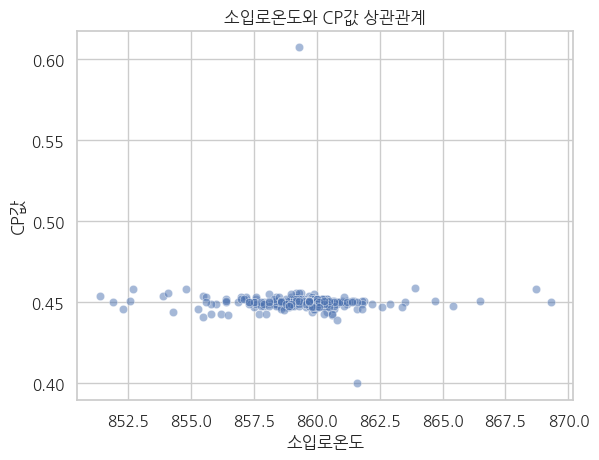

In [58]:
# 간단한 산점도 그리기
sns.scatterplot(data=df, x='소입로온도', y='CP값', alpha=0.5)
plt.title('소입로온도와 CP값 상관관계')
plt.show()


## 실습 1. 산점도로 두 변수 관계 보기
scatterplot으로 두 센서의 관계를 점으로 확인

목표
- scatterplot으로 두 센서의 관계를 점으로 확인

단계
- x·y에 두 센서를 지정해 산점도 그리기
- alpha로 겹친 점을 반투명 처리
- 제목·축 이름을 붙이고 관계 방향 읽기

예상 결과
- 온도가 오를 때 압력이 낮아지는 음의 관계 경향

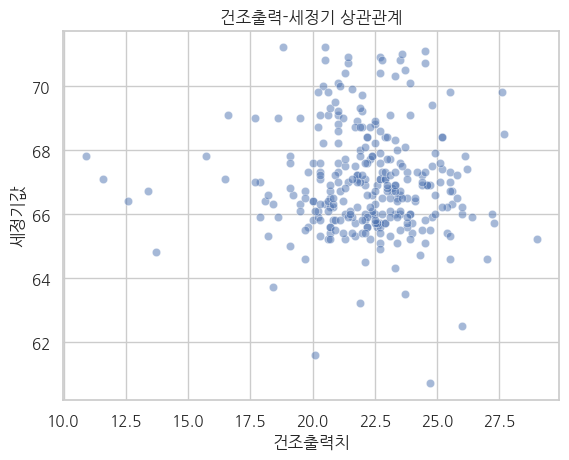

In [63]:
sns.scatterplot(data=df, x='건조출력', y='세정기', alpha=0.5)
plt.title('건조출력-세정기 상관관계')
plt.xlabel('건조출력치')
plt.ylabel('세정기값')
plt.show()

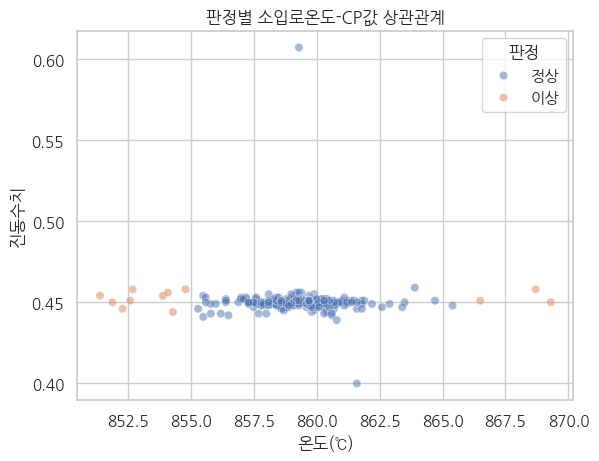

In [67]:
# hue로 그룹 구분해 패턴찾기
sns.scatterplot(data=df, x='소입로온도', y='CP값', hue='판정', alpha=0.5)
plt.title('판정별 소입로온도-CP값 상관관계')
plt.xlabel('온도(℃)')
plt.ylabel('진동수치')
plt.show()

## 실습 2. 판정별 산점도 패턴
hue로 양품·불량을 색 구분해 위험 영역 찾기

목표
- hue로 양품·불량을 색으로 구분해 위험 영역 찾기

단계
- x·y에 두 센서, hue에 판정을 지정
- 산점도에서 불량 점이 몰린 영역 확인
- 어느 영역이 위험 영역인지 해석

예상 결과
- 불량 점이 온도·전류가 함께 높은 영역에 모임

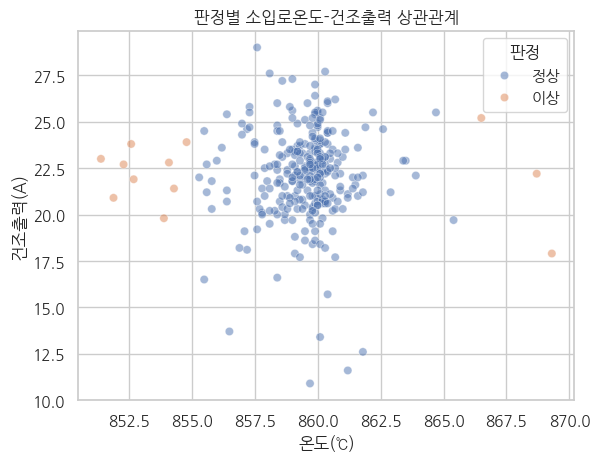

In [68]:
# hue로 그룹 구분해 패턴찾기
sns.scatterplot(data=df, x='소입로온도', y='건조출력', hue='판정', alpha=0.5)
plt.title('판정별 소입로온도-건조출력 상관관계')
plt.xlabel('온도(℃)')
plt.ylabel('건조출력(A)')
plt.show()

In [71]:
# 상관관계 : -1 ~ 1
corr = df.corr(numeric_only=True)
print(corr.round(2))

print('소입력온-제어출력 상관:', df['소입로온도'].corr(df['제어출력']).round(2))

       소입로온도  제어출력  건조출력   세정기   CP값
소입로온도   1.00 -0.74 -0.01  0.03 -0.03
제어출력   -0.74  1.00  0.09 -0.02  0.01
건조출력   -0.01  0.09  1.00 -0.05 -0.10
세정기     0.03 -0.02 -0.05  1.00 -0.04
CP값    -0.03  0.01 -0.10 -0.04  1.00
소입력온-제어출력 상관: -0.74


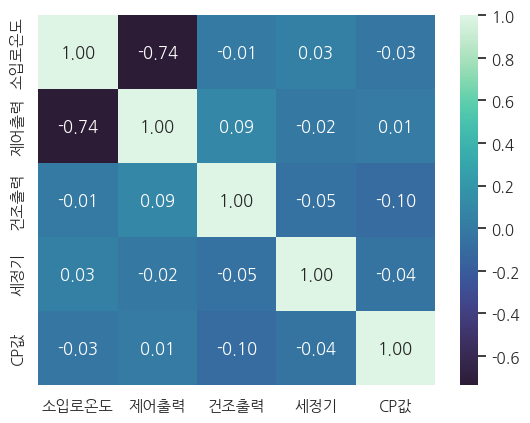

In [79]:
# 간단한 상관관계 히트맵
# cmap의 컬러팔레트는 다음 웹사이트 참고
# https://seaborn.pydata.org/tutorial/color_palettes.html$0

sns.heatmap(data=corr, annot=True, fmt='.2f', cmap='mako', center=0)
plt.show()

## 실습 3. 센서 상관관계 heatmap
상관행렬을 heatmap으로 그리고 강한 쌍을 정리

목표
- 상관행렬을 heatmap으로 그리고 강한 관계 쌍 정리

단계
- corr로 숫자 컬럼끼리 상관행렬 만들기
- heatmap에 annot·cmap·center를 주어 색과 숫자로 표현
- ~대각선 제외 절댓값이 큰 쌍의 상관계수 확인~

예상 결과
- 온도-전류 0.51(강한 양), 온도-압력 -0.24 등

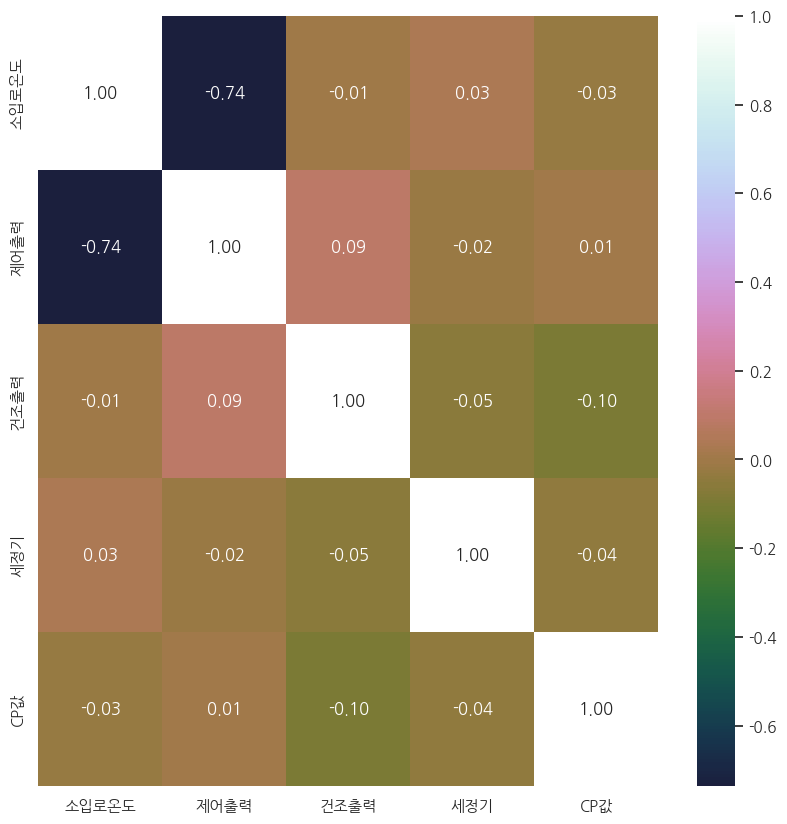

In [84]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(data=corr, annot=True, fmt='0.2f', cmap='cubehelix', center=0)
plt.show()

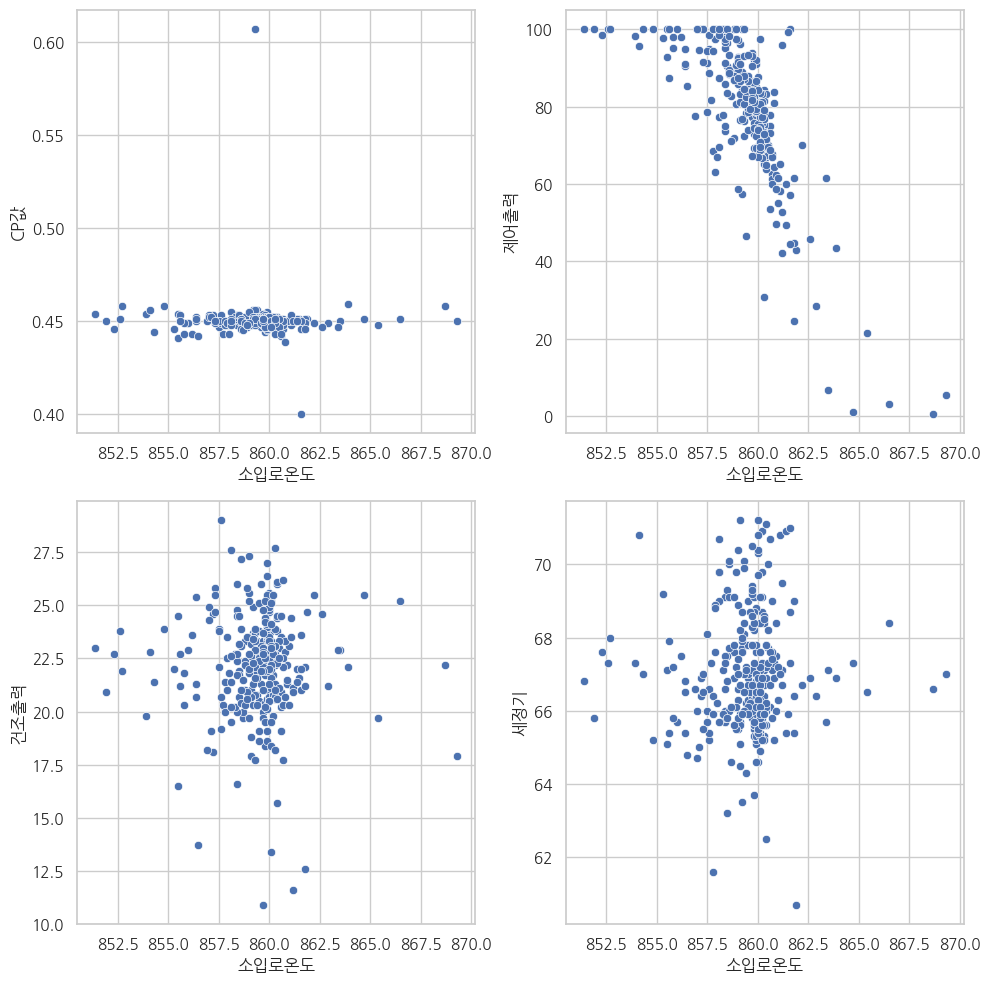

In [86]:
# 간단한 subplot 활용

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
sns.scatterplot(data=df, x='소입로온도', y='CP값', ax=axs[0, 0])
sns.scatterplot(data=df, x='소입로온도', y='제어출력', ax=axs[0, 1])
sns.scatterplot(data=df, x='소입로온도', y='건조출력', ax=axs[1, 0])
sns.scatterplot(data=df, x='소입로온도', y='세정기', ax=axs[1, 1])
plt.tight_layout()
plt.show()



## 실습 4. 종합 리포트— 분포·박스플롯
한 화면에 개수·분포·박스플롯을 나란히 배치

목표
- subplots로 개수·분포·박스플롯을 한 화면에 배치

단계
- subplots로 가로 3칸을 만들기
- 각 칸에 라인별 개수·온도 분포·진동 박스플롯을 그리기
- 각 축에 제목을 달고 tight_layout으로 정리

예상 결과
- 개수·분포·박스플롯이 나란한 3칸 리포트

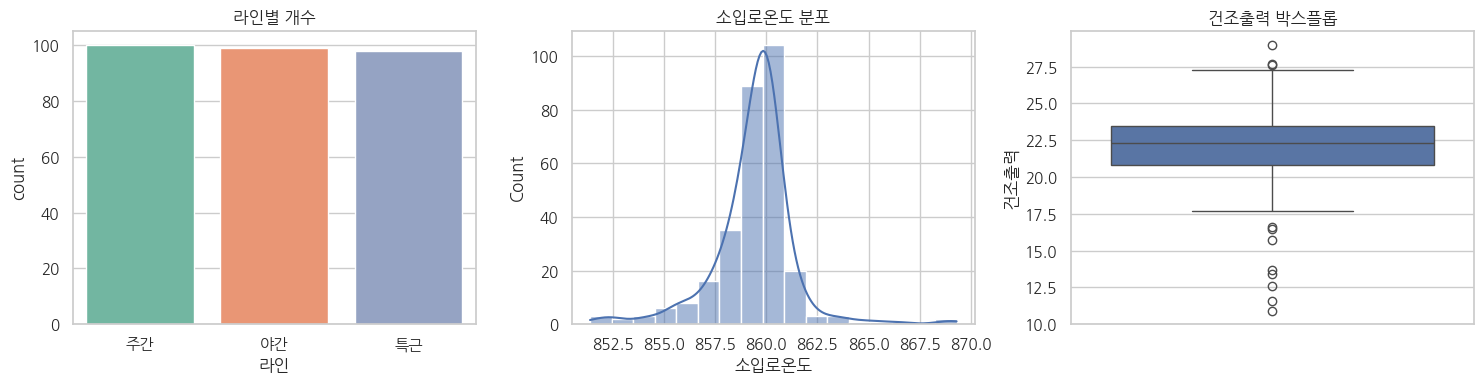

In [105]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='라인', hue='라인', palette='Set2', legend=False, ax=axs[0])
axs[0].set_title('라인별 개수')

sns.histplot(data=df, x='소입로온도', bins=17, kde=True, ax=axs[1])
axs[1].set_title('소입로온도 분포')

sns.boxplot(data=df, y='건조출력', ax=axs[2])
axs[2].set_title('건조출력 박스플롭')

plt.tight_layout()
plt.show()

## 실습 5. 종합 리포트— 산점도·heatmap
관계 그래프 두 가지를 한 화면에 배치

목표
- subplots로 산점도와 상관 heatmap을 한 화면에 배치

단계
- subplots로 가로 2칸을 만들기
- 왼쪽에 판정별 산점도, 오른쪽에 상관 heatmap 그리기
- 각 축에 제목을 달고 tight_layout으로 정리

예상 결과
- 판정별 산점도와 상관 heatmap이 나란한 리포트

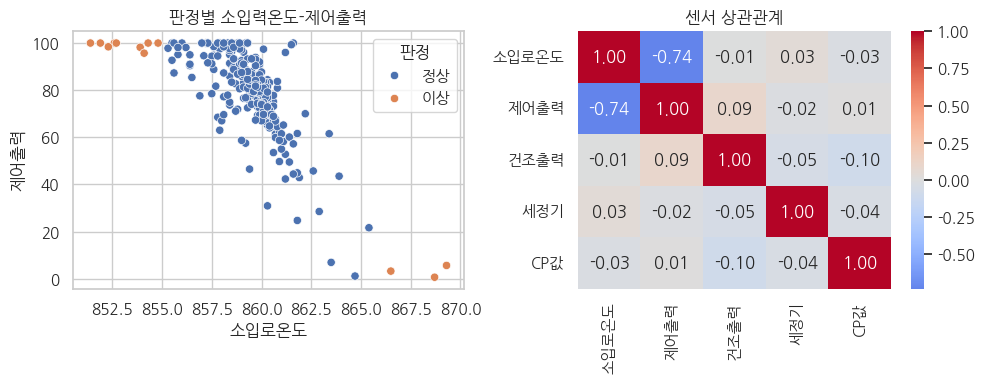

In [115]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.scatterplot(data=df, x='소입로온도', y='제어출력', hue='판정', ax=axs[0])
axs[0].set_title('판정별 소입력온도-제어출력')

corr = df.corr(numeric_only=True)

sns.heatmap(data=corr, annot=True, fmt='0.2f', cmap='coolwarm', center=0, ax=axs[1])
axs[1].set_title('센서 상관관계')

plt.tight_layout()
plt.show()

## 실습 6. 시각화 리포트 통합·저장
핵심 그래프 4개를 2×2로 모아 리포트로 저장

목표
- 핵심 그래프 4개를 2×2로 모아 리포트 파일로 저장

단계
- subplots로 2×2 격자를 만들기
- 분포·박스플롯·산점도·heatmap을 네 칸에 배치
- savefig로 리포트를 이미지 파일로 저장(show보다 먼저)

예상 결과
- 분포·박스·관계·상관을 담은 2×2 리포트 저장

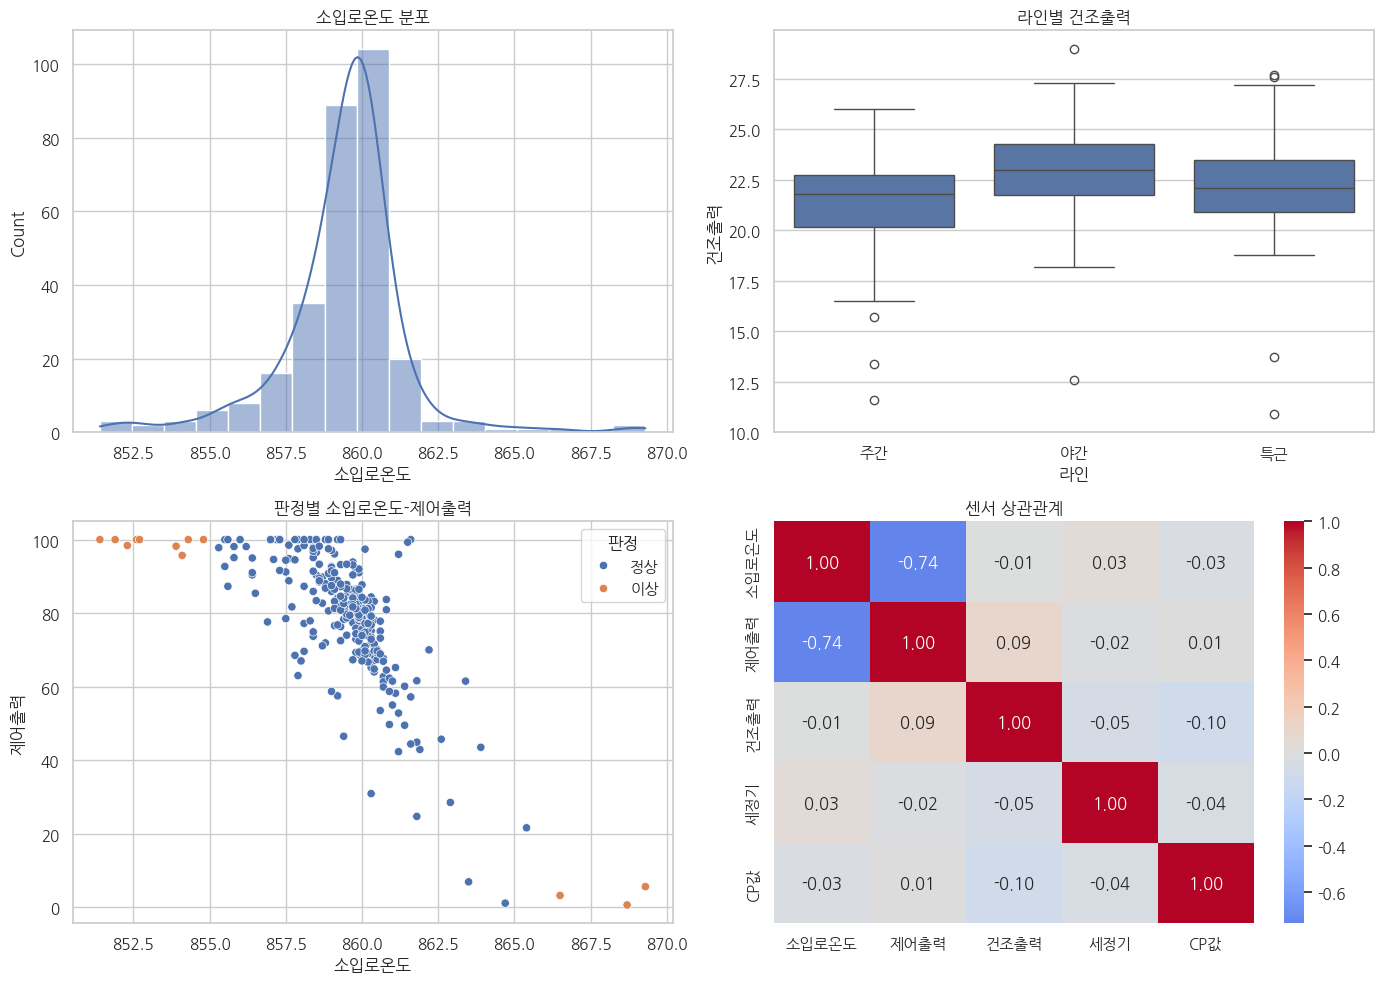

In [122]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x='소입로온도', bins=17, kde=True, ax=axs[0][0])
axs[0][0].set_title('소입로온도 분포')

sns.boxplot(data=df, x='라인', y='건조출력', ax=axs[0][1])
axs[0][1].set_title('라인별 건조출력')

sns.scatterplot(data=df, x='소입로온도', y='제어출력', hue='판정', ax=axs[1][0])
axs[1][0].set_title('판정별 소입로온도-제어출력')

sns.heatmap(data=df.corr(numeric_only=True), annot=True, fmt='0.2f', cmap='coolwarm', center=0, ax=axs[1][1])
axs[1][1].set_title('센서 상관관계')

plt.tight_layout()
plt.show()